In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.model_selection import LeaveOneOut,LeavePOut,KFold,StratifiedKFold,cross_val_score

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: xlabel='cgpa', ylabel='score'>

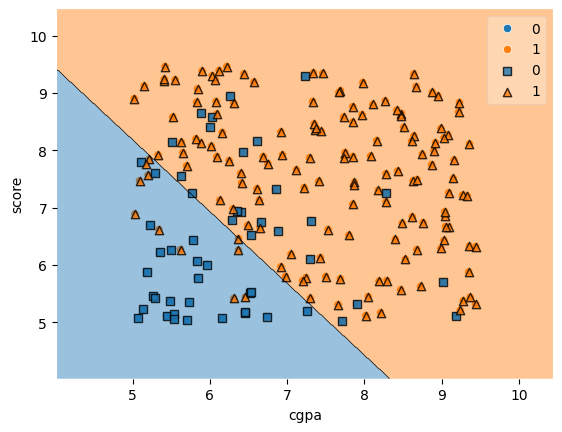

In [57]:
dataset = pd.read_csv("../datasets/cgpa_score_placement.csv")
dataset.columns = dataset.columns.str.strip()
dataset.head()
dataset.isnull().sum()
sns.scatterplot(x="cgpa",y="score",data=dataset,hue="placed")
x = dataset.iloc[:,:-1]
y = dataset["placed"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=13)
sv = SVC(kernel="linear")
sv.fit(x_train,y_train)
sv.score(x_test,y_test)*100
sv.score(x_train,y_train)*100
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=sv)

   data1  data2  output
0   1.75   0.36       1
1   0.79   0.56       0
2   1.97   1.08       1
3   3.28   1.05       1
4   0.65  -1.38       1
data1     0
data2     0
output    0
dtype: int64


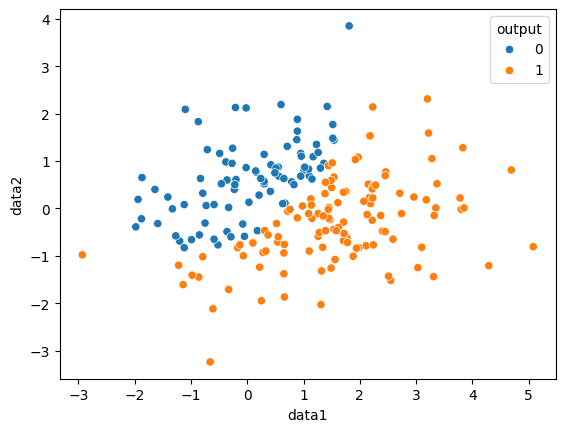

92.5
93.75


c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: >

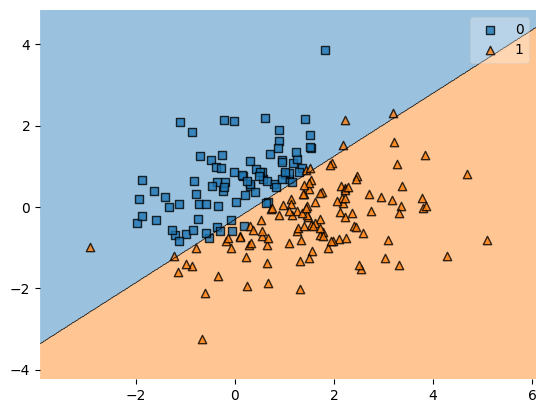

In [58]:
dataset = pd.read_csv("../datasets/logistic_dataset.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.scatterplot(x="data1",y="data2",data=dataset,hue="output")
plt.show()
x = dataset.iloc[:,:-1]
y = dataset["output"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=23)
sv = SVC(kernel="linear")
sv.fit(x_train,y_train)
print(sv.score(x_test,y_test)*100)
print(sv.score(x_train,y_train)*100)
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=sv)

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57
cgpa       0
package    0
dtype: int64


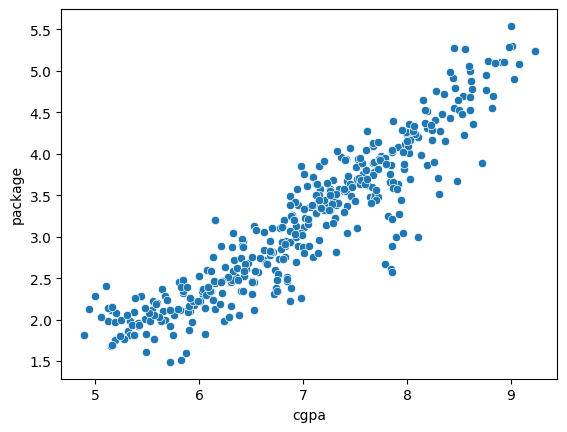

85.92664408860287
85.37610855707402


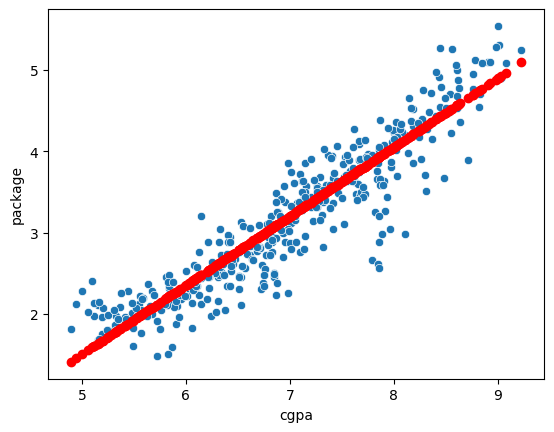

In [59]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.show()
x = dataset[["cgpa"]]
y = dataset["package"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
sv = SVR(kernel="linear",degree=3)
sv.fit(x_train,y_train)
print(sv.score(x_test,y_test)*100)
print(sv.score(x_train,y_train)*100)
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.scatter(dataset["cgpa"],sv.predict(x),color='red')
plt.show()
# plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=sv) level_salary

      Level  Salary
0  1.000000   60000
1  1.095477   62478
2  1.190955   65138
3  1.286432   67981
4  1.381910   71006
Level     0
Salary    0
dtype: int64


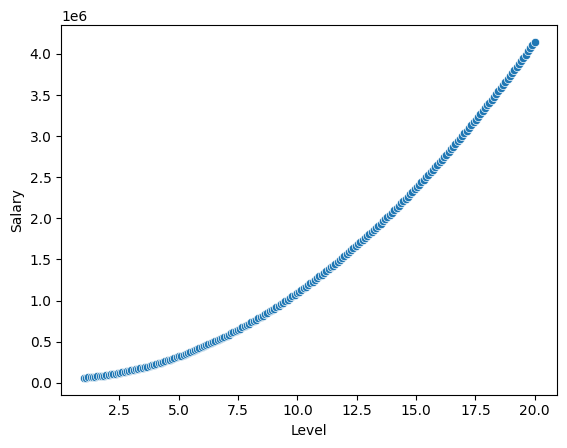

81.2770155440956
83.66451250415943


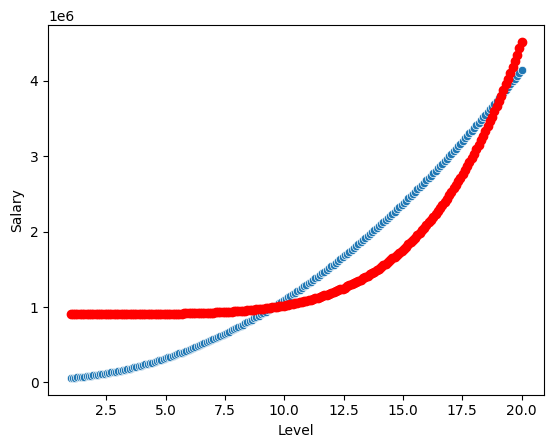

In [60]:
dataset = pd.read_csv("../datasets/level_salary.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.scatterplot(x="Level",y="Salary",data=dataset)
plt.show()
x = dataset[["Level"]]
y = dataset["Salary"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
sv = SVR(kernel="poly",degree=5)
sv.fit(x_train,y_train)
print(sv.score(x_test,y_test)*100)
print(sv.score(x_train,y_train)*100)
sns.scatterplot(x="Level",y="Salary",data=dataset)
plt.scatter(dataset["Level"],sv.predict(x),color='red')
plt.show()

      Level  Salary
0  1.000000   60000
1  1.095477   62478
2  1.190955   65138
3  1.286432   67981
4  1.381910   71006
Level     0
Salary    0
dtype: int64


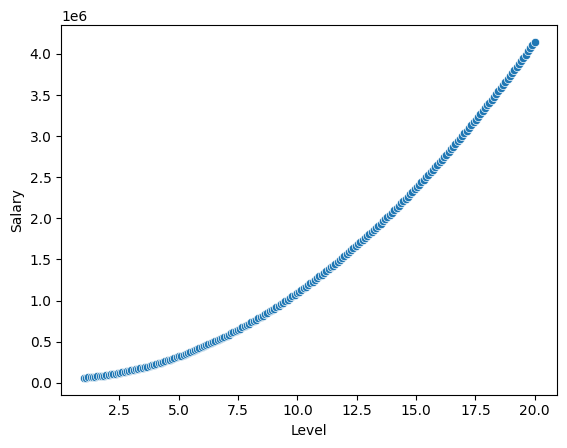

99.94977240682181
99.99999876364544
{'splitter': 'best', 'max_depth': 15, 'criterion': 'squared_error'}
99.9374866328278
{'criterion': 'squared_error', 'max_depth': 9, 'splitter': 'best'}
99.9374866328278


In [61]:
dataset = pd.read_csv("../datasets/level_salary.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.scatterplot(x="Level",y="Salary",data=dataset)
plt.show()
x = dataset.iloc[:,:-1]
y = dataset["Salary"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = DecisionTreeRegressor(criterion="squared_error",max_depth=9,splitter="best")
dt.fit(x_train,y_train)
print(dt.score(x_test,y_test)*100)
print(dt.score(x_train,y_train)*100)
# sns.scatterplot(x="Level",y="Salary",data=dataset)
# plt.scatter(dataset["Level"],sv.predict(x),color='red')
# plt.show()
df = {
    "criterion": ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    "splitter": ["best","random"],
    "max_depth": [i for i in range(2,20)]
}
rd=RandomizedSearchCV(DecisionTreeRegressor(),param_distributions=df,n_iter=20)
rd.fit(x_train,y_train)
print(rd.best_params_)
print(rd.best_score_*100)
gd= GridSearchCV(DecisionTreeRegressor(),param_grid=df)
gd.fit(x_train,y_train)
print(gd.best_params_)
print(gd.best_score_*100)

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57
cgpa       0
package    0
dtype: int64


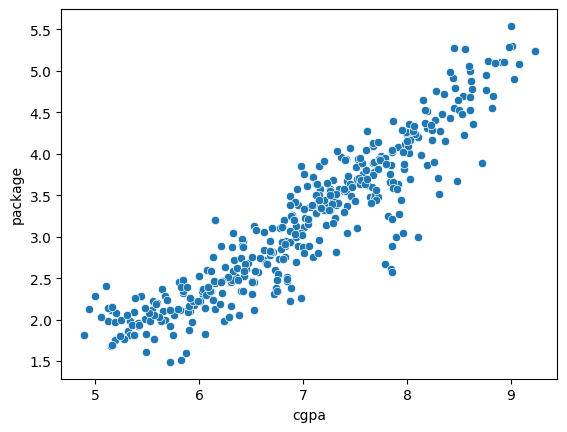

[1 2 3 4 5 6 7 8 9] [0]
[0 2 3 4 5 6 7 8 9] [1]
[0 1 3 4 5 6 7 8 9] [2]
[0 1 2 4 5 6 7 8 9] [3]
[0 1 2 3 5 6 7 8 9] [4]
[0 1 2 3 4 6 7 8 9] [5]
[0 1 2 3 4 5 7 8 9] [6]
[0 1 2 3 4 5 6 8 9] [7]
[0 1 2 3 4 5 6 7 9] [8]
[0 1 2 3 4 5 6 7 8] [9]
[2 3 4 5 6 7 8 9] [0 1]
[1 3 4 5 6 7 8 9] [0 2]
[1 2 4 5 6 7 8 9] [0 3]
[1 2 3 5 6 7 8 9] [0 4]
[1 2 3 4 6 7 8 9] [0 5]
[1 2 3 4 5 7 8 9] [0 6]
[1 2 3 4 5 6 8 9] [0 7]
[1 2 3 4 5 6 7 9] [0 8]
[1 2 3 4 5 6 7 8] [0 9]
[0 3 4 5 6 7 8 9] [1 2]
[0 2 4 5 6 7 8 9] [1 3]
[0 2 3 5 6 7 8 9] [1 4]
[0 2 3 4 6 7 8 9] [1 5]
[0 2 3 4 5 7 8 9] [1 6]
[0 2 3 4 5 6 8 9] [1 7]
[0 2 3 4 5 6 7 9] [1 8]
[0 2 3 4 5 6 7 8] [1 9]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 3 5 6 7 8 9] [2 4]
[0 1 3 4 6 7 8 9] [2 5]
[0 1 3 4 5 7 8 9] [2 6]
[0 1 3 4 5 6 8 9] [2 7]
[0 1 3 4 5 6 7 9] [2 8]
[0 1 3 4 5 6 7 8] [2 9]
[0 1 2 5 6 7 8 9] [3 4]
[0 1 2 4 6 7 8 9] [3 5]
[0 1 2 4 5 7 8 9] [3 6]
[0 1 2 4 5 6 8 9] [3 7]
[0 1 2 4 5 6 7 9] [3 8]
[0 1 2 4 5 6 7 8] [3 9]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 5 7 8 9

In [64]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.columns = dataset.columns.str.strip()
print(dataset.head())
print(dataset.isnull().sum())
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.show()
x = dataset.iloc[:,:-1]
y = dataset["package"]
new_data =dataset.head(10)
x_new = new_data.iloc[:,:-1]
y_new = new_data["package"]
lo = LeaveOneOut()
for train, test in lo.split(x_new,y_new):
    print(train,test)
lp = LeavePOut(p=2)
for train, test in lp.split(x_new,y_new):
    print(train,test)
kf = KFold(n_splits=5)
for train, test in kf.split(x_new,y_new):
    print(train,test)
p=cross_val_score(LinearRegression(),x,y,cv=10)
p.sort()
print(p*100)
# x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
# dt = DecisionTreeRegressor(criterion="squared_error",max_depth=9,splitter="best")
# dt.fit(x_train,y_train)
# print(dt.score(x_test,y_test)*100)
# print(dt.score(x_train,y_train)*100)
# sns.scatterplot(x="Level",y="Salary",data=dataset)
# plt.scatter(dataset["Level"],sv.predict(x),color='red')
# plt.show()
# df = {
#     "criterion": ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
#     "splitter": ["best","random"],
#     "max_depth": [i for i in range(2,20)]
# }
# rd=RandomizedSearchCV(DecisionTreeRegressor(),param_distributions=df,n_iter=20)
# rd.fit(x_train,y_train)
# print(rd.best_params_)
# print(rd.best_score_*100)
# gd= GridSearchCV(DecisionTreeRegressor(),param_grid=df)
# gd.fit(x_train,y_train)
# print(gd.best_params_)
# print(gd.best_score_*100)